# 07 · Survival Models

Predict each patient's survival curve using all 4,024 patients, including censored ones. Library: scikit-survival.

| Model | Assumes proportional hazards |
|---|---|
| Cox, ridge penalty (Cox, 1972) | yes |
| Coxnet, elastic net (Simon et al., 2011) | yes |
| Random survival forest (Ishwaran et al., 2008) | no |
| Gradient-boosted Cox trees (Friedman, 2001) | no |

Metrics: Harrell's and Uno's C-index, time-dependent AUC at 36/60/84 months, integrated Brier score against a Kaplan–Meier baseline.

In [1]:
import sys, warnings, json
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import (concordance_index_censored, cumulative_dynamic_auc, brier_score)
from sksurv.nonparametric import kaplan_meier_estimator
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

from seer_survival import config as C
from seer_survival.data import load_clean
from seer_survival.models import survival_zoo, make_survival_pipeline
from seer_survival.targets import make_surv
from seer_survival.training import make_split, cv_survival, summarise_cv, select_one_se, fit_final_survival
from seer_survival.evaluate import survival_metrics, km_baseline_ibs
from seer_survival.plots import set_style, save_fig, PALETTE

set_style()
df = load_clean()
s = make_split(df)
Xtr, Xte = s["X_train"], s["X_test"]
y_tr, y_te = make_surv(s["t_train"], s["e_train"]), make_surv(s["t_test"], s["e_test"])
times = np.array(C.EVAL_TIMES, dtype=float)
print(f"train: {len(Xtr)} ({y_tr['event'].sum()} events) | test: {len(Xte)} ({y_te['event'].sum()} events)")

train: 3219 (493 events) | test: 805 (123 events)


## 1. Cross-validated comparison (training split)

In [2]:
cv_scores = cv_survival(Xtr, s["t_train"], s["e_train"])
summ_c = summarise_cv(cv_scores, "c_index")
summ_c["ibs_mean"] = cv_scores.groupby("model")["ibs"].mean()
summ_c["ibs_sd"] = cv_scores.groupby("model")["ibs"].std()
summ_c.round(4)

,mean,sd,n_folds,se,complexity,ibs_mean,ibs_sd
model,,,,,,,
Random Survival Forest,0.7375,0.0156,5,0.0070,2,0.0909,0.0030
Coxnet (elastic net),0.7369,0.0150,5,0.0067,1,0.0908,0.0031
Cox PH (ridge),0.7356,0.0155,5,0.0069,1,0.0911,0.0035
Gradient Boosted Survival,0.7350,0.0139,5,0.0062,2,0.0927,0.0031


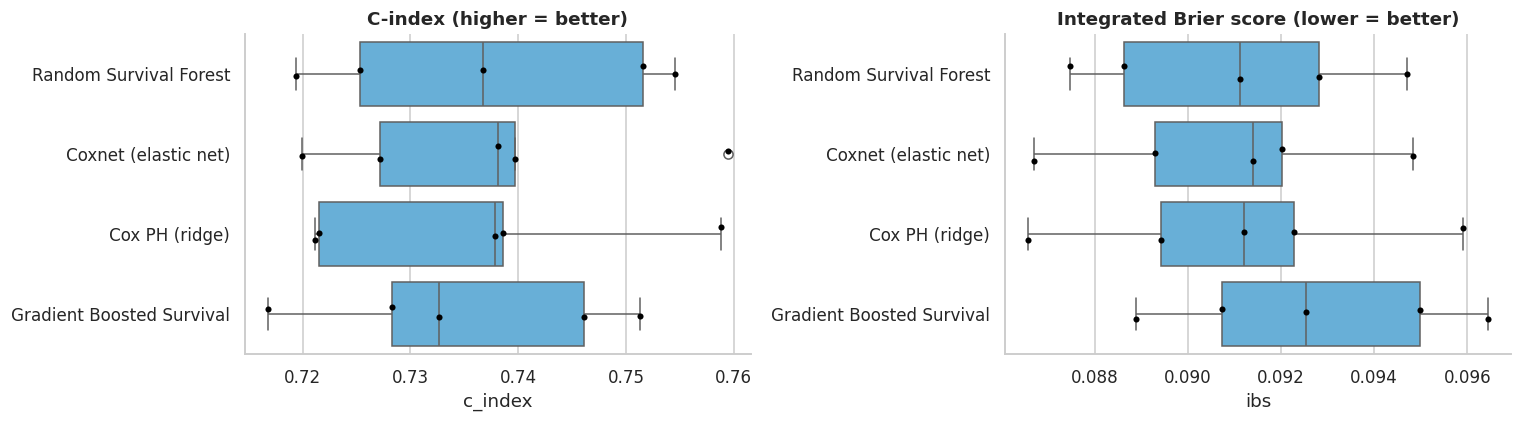

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
order = summ_c.index.tolist()
for ax, metric, title in [(axes[0], "c_index", "C-index (higher = better)"), (axes[1], "ibs", "Integrated Brier score (lower = better)")]:
    sns.boxplot(data=cv_scores, y="model", x=metric, order=order, color=PALETTE[5], ax=ax)
    sns.stripplot(data=cv_scores, y="model", x=metric, order=order, color="k", size=4, ax=ax)
    ax.set_title(title); ax.set_ylabel("")
fig.tight_layout(); save_fig(fig, "07_cv_survival_models"); plt.show()

In [4]:
selected = select_one_se(summ_c)
print("Selected by the one-standard-error rule:", selected)

Selected by the one-standard-error rule: Coxnet (elastic net)


## 2. Tuning checks

### 2a. Coxnet regularisation path
The default Coxnet uses a fixed α = 0.01. Here the whole α path is cross-validated to see whether that choice matters.

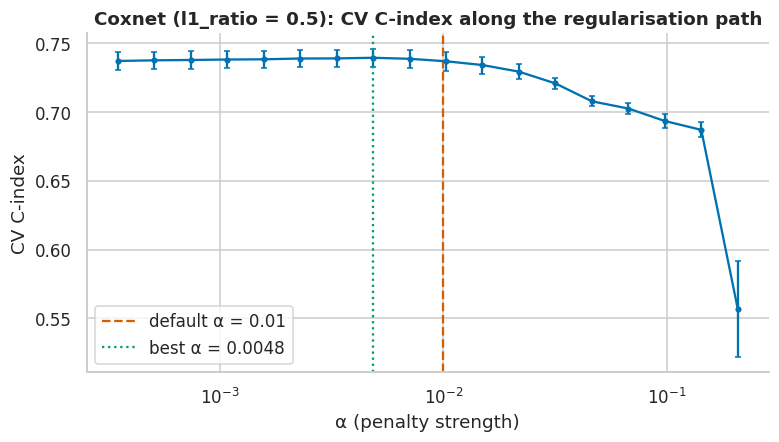

best α=0.0048: C=0.7393 ± 0.0065 | default α=0.01 (from section 1): C=0.7369


In [5]:
cv = StratifiedKFold(5, shuffle=True, random_state=C.RANDOM_STATE)
prep = make_survival_pipeline(CoxnetSurvivalAnalysis(l1_ratio=0.5, n_alphas=50, max_iter=100000), scale=True)
prep.fit(Xtr, y_tr)
alphas = prep.named_steps["model"].alphas_
alphas = alphas[::2]
scores = np.zeros((5, len(alphas)))
for k, (tr, va) in enumerate(cv.split(Xtr, s["e_train"])):
    for j, a in enumerate(alphas):
        pipe = make_survival_pipeline(CoxnetSurvivalAnalysis(l1_ratio=0.5, alphas=[a], max_iter=100000), scale=True)
        pipe.fit(Xtr.iloc[tr], y_tr[tr])
        scores[k, j] = concordance_index_censored(y_tr["event"][va], y_tr["time"][va], pipe.predict(Xtr.iloc[va]))[0]
mean, se = scores.mean(0), scores.std(0, ddof=1) / np.sqrt(5)
best_j = mean.argmax()
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(alphas, mean, yerr=se, fmt="o-", ms=3, capsize=2)
ax.axvline(0.01, c=PALETTE[1], ls="--", label="default α = 0.01")
ax.axvline(alphas[best_j], c=PALETTE[2], ls=":", label=f"best α = {alphas[best_j]:.4f}")
ax.set_xscale("log"); ax.set_xlabel("α (penalty strength)"); ax.set_ylabel("CV C-index"); ax.legend()
ax.set_title("Coxnet (l1_ratio = 0.5): CV C-index along the regularisation path")
save_fig(fig, "07_coxnet_path"); plt.show()
print(f"best α={alphas[best_j]:.4f}: C={mean[best_j]:.4f} ± {se[best_j]:.4f} | default α=0.01 (from section 1): C={summ_c.loc['Coxnet (elastic net)', 'mean']:.4f}")

### 2b. Random Survival Forest: leaf size and feature sampling

In [6]:
grid = [{"min_samples_leaf": l, "max_features": f} for l in (5, 15, 30, 60) for f in ("sqrt", 0.5)]
rows = []
for g in grid:
    cs = []
    for tr, va in cv.split(Xtr, s["e_train"]):
        pipe = make_survival_pipeline(RandomSurvivalForest(n_estimators=200, n_jobs=-1, random_state=C.RANDOM_STATE, **g), scale=False)
        pipe.fit(Xtr.iloc[tr], y_tr[tr])
        cs.append(concordance_index_censored(y_tr["event"][va], y_tr["time"][va], pipe.predict(Xtr.iloc[va]))[0])
    rows.append({**g, "cv_c_mean": np.mean(cs), "cv_c_sd": np.std(cs, ddof=1)})
rsf_grid = pd.DataFrame(rows).sort_values("cv_c_mean", ascending=False)
rsf_grid.round(4)

,min_samples_leaf,max_features,cv_c_mean,cv_c_sd
4,30,sqrt,0.7383,0.0158
2,15,sqrt,0.7379,0.0150
6,60,sqrt,0.7374,0.0175
5,30,0.5,0.7367,0.0153
3,15,0.5,0.7340,0.0146
7,60,0.5,0.7335,0.0156
0,5,sqrt,0.7276,0.0162
1,5,0.5,0.7187,0.0179


## 3. Test set

The selected model is refit on the training split and evaluated once. The other models are shown for reference.

In [7]:
test_rows = {}
fitted = {}
for name in survival_zoo():
    mdl = fit_final_survival(name, Xtr, s["t_train"], s["e_train"])
    fitted[name] = mdl
    test_rows[name] = survival_metrics(mdl, Xte, y_tr, y_te, times)
test_tab = pd.DataFrame(test_rows).T
ibs_km = km_baseline_ibs(y_tr, y_te, times)
test_tab["IBS skill vs KM"] = 1 - test_tab["ibs"] / ibs_km
print(f"Kaplan-Meier (no covariates) IBS on test: {ibs_km:.4f}")
print(f"Selected model: {selected}")
test_tab.round(4)

Kaplan-Meier (no covariates) IBS on test: 0.1030
Selected model: Coxnet (elastic net)


,c_harrell,c_uno,mean_td_auc,ibs,td_auc_36m,td_auc_60m,td_auc_84m,IBS skill vs KM
Cox PH (ridge),0.7229,0.7009,0.7469,0.0911,0.7884,0.7378,0.7017,0.1157
Coxnet (elastic net),0.7115,0.6934,0.7312,0.0916,0.7604,0.7287,0.6946,0.1108
Random Survival Forest,0.7139,0.6955,0.7372,0.0921,0.7733,0.7278,0.6997,0.1062
Gradient Boosted Survival,0.7189,0.7023,0.7446,0.0916,0.7817,0.7328,0.7085,0.1105


**Bootstrap 95 % CI for the selected model's test C-index**

In [8]:
rng = np.random.default_rng(C.RANDOM_STATE)
risk_sel = fitted[selected].predict(Xte)
boot = []
for _ in range(1000):
    idx = rng.integers(0, len(Xte), len(Xte))
    if y_te["event"][idx].sum() < 2:
        continue
    boot.append(concordance_index_censored(y_te["event"][idx], y_te["time"][idx], risk_sel[idx])[0])
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"{selected}: Harrell C = {test_tab.loc[selected, 'c_harrell']:.3f} (95% CI {lo:.3f}-{hi:.3f})")

Coxnet (elastic net): Harrell C = 0.711 (95% CI 0.663-0.759)


## 4. Performance over time

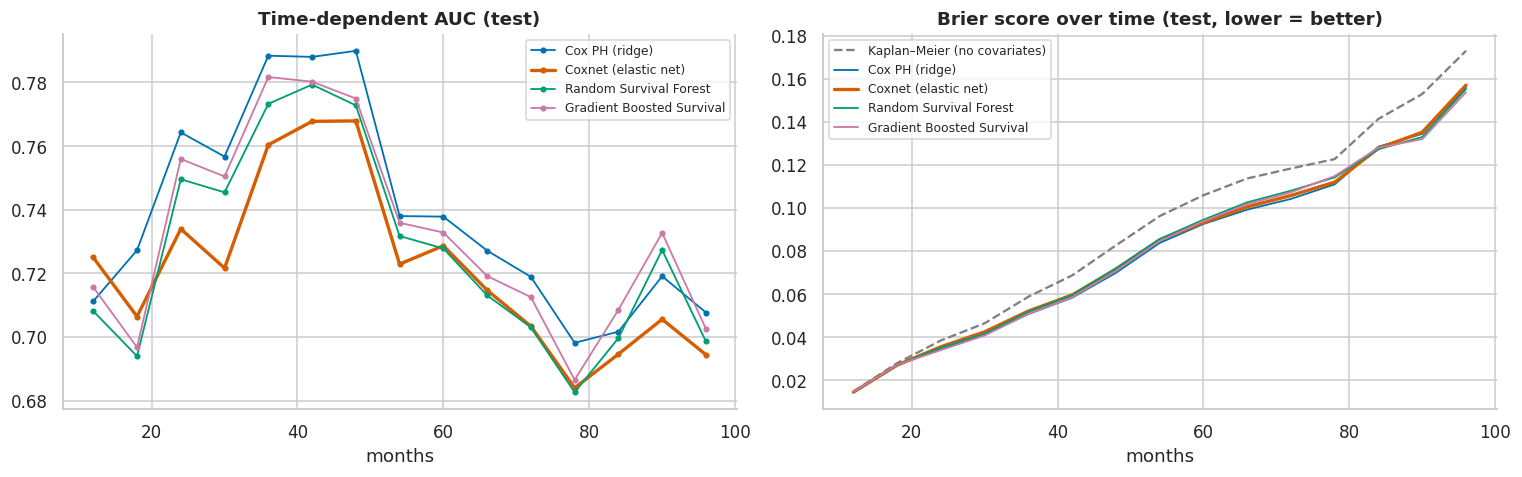

In [9]:
grid_t = np.arange(12, 97, 6, dtype=float)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
t_km, s_km = kaplan_meier_estimator(y_tr["event"], y_tr["time"])
km_at = lambda tt: np.array([s_km[t_km <= t][-1] if (t_km <= t).any() else 1.0 for t in tt])
_, bs_km = brier_score(y_tr, y_te, np.tile(km_at(grid_t), (len(y_te), 1)), grid_t)
axes[1].plot(grid_t, bs_km, c="grey", ls="--", label="Kaplan–Meier (no covariates)")
for i, (name, mdl) in enumerate(fitted.items()):
    auc_t, _ = cumulative_dynamic_auc(y_tr, y_te, mdl.predict(Xte), grid_t)
    axes[0].plot(grid_t, auc_t, marker="o", ms=3, c=PALETTE[i], label=name, lw=2.2 if name == selected else 1.2)
    surv = np.vstack([fn(grid_t) for fn in mdl.predict_survival_function(Xte)])
    _, bs = brier_score(y_tr, y_te, surv, grid_t)
    axes[1].plot(grid_t, bs, c=PALETTE[i], label=name, lw=2.2 if name == selected else 1.2)
axes[0].set_title("Time-dependent AUC (test)"); axes[0].set_xlabel("months"); axes[0].legend(fontsize=8)
axes[1].set_title("Brier score over time (test, lower = better)"); axes[1].set_xlabel("months"); axes[1].legend(fontsize=8)
fig.tight_layout(); save_fig(fig, "07_time_dependent_metrics"); plt.show()

## 5. Calibration at 60 months

Test patients are grouped into deciles of predicted 5-year survival. For each decile, the observed Kaplan–Meier survival at 60 months (which handles censoring properly) is compared with the mean prediction.

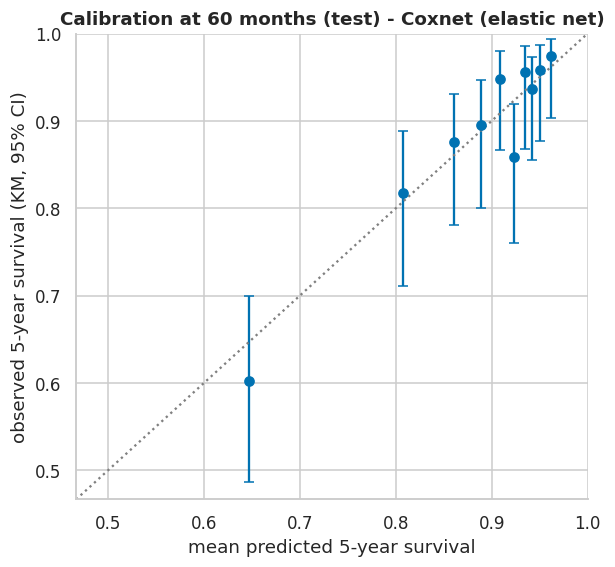

,decile,n,predicted S(60),observed KM S(60),lo,hi
0,1,81,0.647,0.602,0.487,0.700
1,2,80,0.807,0.818,0.711,0.888
2,3,81,0.860,0.875,0.781,0.931
3,4,80,0.889,0.895,0.801,0.946
4,5,81,0.909,0.948,0.867,0.980
5,6,80,0.924,0.859,0.760,0.920
6,7,80,0.935,0.956,0.867,0.986
7,8,81,0.942,0.937,0.855,0.973
8,9,80,0.950,0.959,0.877,0.987
9,10,81,0.961,0.975,0.903,0.994


In [10]:
mdl = fitted[selected]
pred60 = np.array([fn(60.0) for fn in mdl.predict_survival_function(Xte)])
dec = pd.qcut(pred60, 10, labels=False, duplicates="drop")
rows = []
for d in np.unique(dec):
    m = dec == d
    k = KaplanMeierFitter().fit(y_te["time"][m], y_te["event"][m])
    ci = k.confidence_interval_survival_function_
    obs = float(k.survival_function_at_times(60).iloc[0])
    lo_ = float(ci[ci.index <= 60].iloc[-1, 0]); hi_ = float(ci[ci.index <= 60].iloc[-1, 1])
    rows.append({"decile": d + 1, "n": int(m.sum()), "predicted S(60)": pred60[m].mean(), "observed KM S(60)": obs, "lo": lo_, "hi": hi_})
cal = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(6, 5.5))
ax.errorbar(cal["predicted S(60)"], cal["observed KM S(60)"], yerr=[cal["observed KM S(60)"] - cal.lo, cal.hi - cal["observed KM S(60)"]],
            fmt="o", capsize=3, c=PALETTE[0])
lims = [cal[["predicted S(60)", "lo"]].min().min() - .02, 1.0]
ax.plot(lims, lims, ls=":", c="grey"); ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("mean predicted 5-year survival"); ax.set_ylabel("observed 5-year survival (KM, 95% CI)")
ax.set_title(f"Calibration at 60 months (test) - {selected}")
save_fig(fig, "07_calibration_60m"); plt.show()
cal.round(3)

## 6. Risk stratification on unseen patients

Cut-offs are the tertiles of predicted risk in the **training** split; they are applied unchanged to the test split. If the model has learned something real, the three test groups should separate clearly.

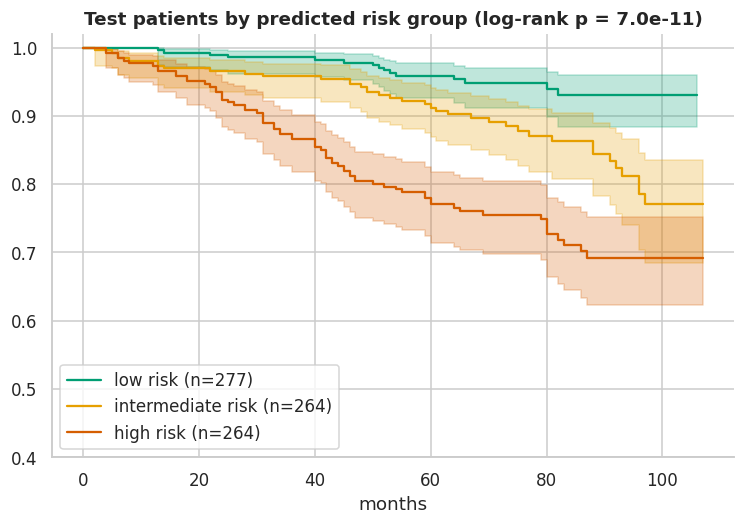

,group,n,deaths,KM S(60)
0,low,277,15,0.958
1,intermediate,264,38,0.912
2,high,264,70,0.771


In [11]:
risk_tr = mdl.predict(Xtr)
cuts = np.quantile(risk_tr, [1/3, 2/3])
grp = np.select([risk_sel < cuts[0], risk_sel < cuts[1]], ["low", "intermediate"], "high")
fig, ax = plt.subplots(figsize=(8, 5))
rows = []
for i, g in enumerate(["low", "intermediate", "high"]):
    m = grp == g
    k = KaplanMeierFitter(label=f"{g} risk (n={m.sum()})").fit(y_te["time"][m], y_te["event"][m])
    k.plot_survival_function(ax=ax, color=[PALETTE[2], PALETTE[4], PALETTE[1]][i])
    rows.append({"group": g, "n": int(m.sum()), "deaths": int(y_te["event"][m].sum()),
                 "KM S(60)": float(k.survival_function_at_times(60).iloc[0])})
lr = multivariate_logrank_test(y_te["time"], grp, y_te["event"])
ax.set_title(f"Test patients by predicted risk group (log-rank p = {lr.p_value:.1e})")
ax.set_xlabel("months"); ax.set_ylim(0.4, 1.02)
save_fig(fig, "07_risk_groups_test"); plt.show()
pd.DataFrame(rows).round(3)

## 7. Consistency check against the saved artefact

In [12]:
meta_path = C.MODELS_DIR / "metadata.json"
if meta_path.exists():
    meta = json.loads(meta_path.read_text())
    print("artefact survival model:", meta["survival_model_name"], "| notebook:", selected)
    print(f"artefact test C: {meta['test_metrics_survival']['c_harrell']:.4f} | notebook: {test_tab.loc[selected, 'c_harrell']:.4f}")
    assert meta["survival_model_name"] == selected
    assert abs(meta["test_metrics_survival"]["c_harrell"] - test_tab.loc[selected, "c_harrell"]) < 1e-6
    print("Consistent.")
else:
    print("Run `python scripts/train.py` first.")

artefact survival model: Coxnet (elastic net) | notebook: Coxnet (elastic net)
artefact test C: 0.7115 | notebook: 0.7115
Consistent.


## Findings

- In CV the four models are within 0.003 C-index (0.735–0.738), well inside one standard error. Coxnet is selected as the simplest.
- Tuning Coxnet's α or the RSF settings gains less than one standard error.

Test results for Coxnet (805 patients, 123 deaths):

| Metric | Value |
|---|---|
| Harrell's C | 0.711 (0.663–0.759) |
| Uno's C | 0.693 |
| Time-dependent AUC, 36 / 60 / 84 months | 0.760 / 0.729 / 0.695 |
| Integrated Brier score | 0.092 (Kaplan–Meier: 0.103) |

- The CV C-index (0.737) lies inside the test CI.
- Cox ridge scored higher on this test split (0.723). The selection was fixed beforehand and is not changed.
- Discrimination drops at longer horizons, in line with the time-varying ER/PR effect.
- Calibration at 60 months is good across deciles.
- Risk groups on test patients: 5-year survival 95.8 % (low), 91.2 % (intermediate), 77.1 % (high).
- Deep survival models were not tried: tree models did not beat linear Cox, and there are only about 490 training events.